# 04 — Demand Estimation and Equity Weighting

This notebook implements **Phase 1** of the revised methodology without changing its formula or notation:

\[
D_i^{(\alpha)}
=
H_iC_i\times P_d\times P_{pub}\times U_i\times(1+\alpha\,IMD_i).
\]

Notation used here:

- \(u_i\): mean observed utilisation of existing on-street charging locations in LSOA \(i\), produced by Notebook 02;
- \(U_i=1+u_i\) where \(e_i>0\), and \(U_i=1\) where \(e_i=0\);
- \(D_i^{(\alpha)}\): equity-adjusted recognised public-charging demand weight;
- demand is **not normalised** across the \(\alpha\) scenarios.

The output is one LSOA-level analytical file used directly by Notebook 05.

## 0. Setup and input paths

The notebook reads only processed outputs from Notebook 02 plus the 2021 LSOA boundary file. Set the `DISSERTATION_BASE` environment variable when the project is stored somewhere other than the default path.

In [2]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

BASE = Path(os.environ.get(
    "DISSERTATION_BASE",
    "/Users/alexia/Documents/CASA/Dissertation",
))
PROCESSED_DIR = BASE / "05_processed"
FIGURES_DIR = BASE / "06_outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    "census": PROCESSED_DIR / "census_london_clean.csv",
    "imd": PROCESSED_DIR / "imd_london_clean.csv",
    "supply": PROCESSED_DIR / "lsoa_supply_clean.csv",
    "boundaries": BASE / "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp",
}

for name, path in PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {name}: {path}")

print("Using project base:", BASE)
print("Processed-data directory:", PROCESSED_DIR)

Using project base: /Users/alexia/Documents/CASA/Dissertation
Processed-data directory: /Users/alexia/Documents/CASA/Dissertation/05_processed


## 1. Load and align the cleaned LSOA inputs

Notebook 02 currently exports its LSOA mean-utilisation field as `U_i`. In the revised methodology that quantity is denoted \(u_i\), while \(U_i\) denotes the utilisation-pressure multiplier. The source column is therefore renamed on import; its values are not changed.

In [3]:
def require_columns(df: pd.DataFrame, required: list[str], name: str) -> None:
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise KeyError(f"{name}: missing required columns {missing}")


census = pd.read_csv(PATHS["census"])
imd = pd.read_csv(PATHS["imd"])
supply_source = pd.read_csv(PATHS["supply"])

require_columns(census, ["lsoa_code", "lsoa_name", "Hi", "Ci"], "census")
require_columns(imd, ["lsoa_code", "income_score"], "imd")
require_columns(
    supply_source,
    ["lsoa_code", "e_i", "U_i", "S_eff_i", "has_evse_i"],
    "supply",
)

# In Notebook 02, U_i is the LSOA mean location utilisation. Under the revised
# Phase 1/2 notation, this is u_i; U_i is constructed below as the multiplier.
supply = supply_source.rename(columns={"U_i": "u_i"}).copy()

analytical = (
    census[["lsoa_code", "lsoa_name", "Hi", "Ci", "vehicle_stock_proxy"]]
    .merge(
        imd[[
            "lsoa_code", "income_score", "income_rank", "income_decile",
        ]],
        on="lsoa_code",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        supply[[
            "lsoa_code", "e_i", "u_i", "S_eff_i", "has_evse_i",
        ]],
        on="lsoa_code",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("lsoa_code")
    .reset_index(drop=True)
)

if len(analytical) != 4_994:
    warnings.warn(f"Expected 4,994 Greater London LSOAs, found {len(analytical):,}.")
if analytical["lsoa_code"].duplicated().any():
    raise ValueError("The analytical input is not one row per LSOA.")
if analytical[["Hi", "Ci", "income_score", "e_i"]].isna().any().any():
    raise ValueError("Missing values found in required demand inputs.")
if not analytical["income_score"].between(0, 1).all():
    raise ValueError("income_score contains values outside [0, 1].")
if not analytical.loc[analytical["e_i"].gt(0), "u_i"].between(0, 1).all():
    raise ValueError("u_i contains values outside [0, 1] where provision exists.")
if analytical.loc[analytical["e_i"].eq(0), "u_i"].notna().any():
    warnings.warn("Some zero-provision LSOAs have non-missing u_i values; inspect Notebook 02.")

print("Aligned analytical LSOAs:", f"{len(analytical):,}")
print("LSOAs with existing on-street provision:", f"{analytical['e_i'].gt(0).sum():,}")
print("LSOAs without existing on-street provision:", f"{analytical['e_i'].eq(0).sum():,}")

Aligned analytical LSOAs: 4,994
LSOAs with existing on-street provision: 3,157
LSOAs without existing on-street provision: 1,837


## 2. Construct the utilisation-pressure multiplier \(U_i\)

\[
U_i=
\begin{cases}
1+u_i, & e_i>0,\\
1, & e_i=0.
\end{cases}
\]

LSOAs without existing provision receive the neutral multiplier \(U_i=1\); they are not treated as having observed zero utilisation pressure.

In [4]:
analytical["U_i"] = np.where(
    analytical["e_i"].gt(0),
    1.0 + analytical["u_i"],
    1.0,
)

if analytical["U_i"].isna().any():
    raise ValueError("U_i contains missing values after applying the neutral rule.")
if not analytical["U_i"].between(1, 2).all():
    raise ValueError("U_i must lie within [1, 2].")
if not analytical.loc[analytical["e_i"].eq(0), "U_i"].eq(1.0).all():
    raise ValueError("Zero-provision LSOAs must receive U_i = 1.")

print("U_i summary:")
print(analytical["U_i"].describe())

U_i summary:
count    4994.000000
mean        1.016706
std         0.029719
min         1.000000
25%         1.000000
50%         1.004001
75%         1.021973
max         1.386982
Name: U_i, dtype: float64


## 3. Estimate baseline public-charging demand

The fixed charging-behaviour parameters are:

\[
P_d=\frac{4.3}{14}\approx0.31,
\qquad
P_{pub}=\frac{1.8}{4.4}\approx0.41.
\]

The household vehicle-stock base is \(V_i=H_iC_i\), and the unweighted baseline demand is:

\[
B_i=H_iC_i\times P_d\times P_{pub}\times U_i.
\]

In [5]:
P_d = 4.3 / 14
P_pub = 1.8 / 4.4

analytical["V_i"] = analytical["Hi"] * analytical["Ci"]
analytical["B_i"] = (
    analytical["V_i"]
    * P_d
    * P_pub
    * analytical["U_i"]
)

if (analytical[["V_i", "B_i"]] < 0).any().any():
    raise ValueError("Negative vehicle-stock or demand values detected.")

print(f"P_d   = {P_d:.6f}")
print(f"P_pub = {P_pub:.6f}")
print("\nB_i summary:")
print(analytical["B_i"].describe())
print("Total B_i:", f"{analytical['B_i'].sum():,.2f}")

P_d   = 0.307143
P_pub = 0.409091

B_i summary:
count    4994.000000
mean       69.513558
std        26.926555
min         8.669805
25%        47.842157
50%        68.198102
75%        90.155749
max       180.306818
Name: B_i, dtype: float64
Total B_i: 347,150.71


## 4. Construct the four equity-weighted demand scenarios

For \(\alpha\in\{0,0.1,0.3,0.5\}\):

\[
D_i^{(\alpha)}=B_i(1+\alpha IMD_i).
\]

The weighting changes recognised planning demand directly. No scenario is rescaled to preserve a fixed London-wide total.

In [6]:
SCENARIOS = {
    "A": 0.0,
    "B": 0.1,
    "C": 0.3,
    "D": 0.5,
}

analytical["IMD_i"] = analytical["income_score"]
for label, alpha in SCENARIOS.items():
    analytical[f"D_{label}"] = analytical["B_i"] * (
        1.0 + alpha * analytical["IMD_i"]
    )

scenario_cols = [f"D_{label}" for label in SCENARIOS]

if not np.allclose(analytical["D_A"], analytical["B_i"]):
    raise ValueError("Scenario A (alpha=0) must reproduce B_i exactly.")
if (analytical[scenario_cols] < 0).any().any():
    raise ValueError("Negative scenario demand values detected.")
if not all(
    analytical[f"D_{right}"].sum() >= analytical[f"D_{left}"].sum()
    for left, right in zip(["A", "B", "C"], ["B", "C", "D"])
):
    raise ValueError("Total recognised demand should not fall as alpha increases.")

scenario_summary = pd.DataFrame([
    {
        "scenario": label,
        "alpha": alpha,
        "total_recognised_demand": analytical[f"D_{label}"].sum(),
        "change_from_alpha0_pct": 100 * (
            analytical[f"D_{label}"].sum() / analytical["D_A"].sum() - 1
        ),
        "mean_lsoa_demand": analytical[f"D_{label}"].mean(),
        "maximum_lsoa_demand": analytical[f"D_{label}"].max(),
    }
    for label, alpha in SCENARIOS.items()
])

print(scenario_summary.to_string(index=False, float_format=lambda value: f"{value:,.4f}"))

scenario  alpha  total_recognised_demand  change_from_alpha0_pct  mean_lsoa_demand  maximum_lsoa_demand
       A 0.0000             347,150.7088                  0.0000           69.5136             180.3068
       B 0.1000             355,754.5117                  2.4784           71.2364             182.1640
       C 0.3000             372,962.1174                  7.4352           74.6820             185.8783
       D 0.5000             390,169.7231                 12.3920           78.1277             189.5926


## 5. Construct London-specific income-deprivation deciles

The official `income_decile` field in the IoD source is an England-wide decile. Phase 4 instead requires ten approximately equal-sized groups formed **within Greater London**. The original field is retained for reference, and a new `london_income_decile` field is created for evaluation.

In [7]:
# Higher Income Domain Score = more income deprived.
# Rank first to obtain deterministic equal-sized groups if any scores are tied.
london_rank = analytical["IMD_i"].rank(
    method="first",
    ascending=False,
)
analytical["london_income_decile"] = pd.qcut(
    london_rank,
    q=10,
    labels=range(1, 11),
).astype(int)

london_decile_counts = (
    analytical["london_income_decile"]
    .value_counts()
    .sort_index()
    .rename_axis("london_income_decile")
    .reset_index(name="n_lsoas")
)

print("London-specific deprivation-decile sizes:")
print(london_decile_counts.to_string(index=False))
print("\nOfficial national income-decile counts within London:")
print(analytical["income_decile"].value_counts().sort_index().to_string())

London-specific deprivation-decile sizes:
 london_income_decile  n_lsoas
                    1      500
                    2      499
                    3      499
                    4      500
                    5      499
                    6      499
                    7      500
                    8      499
                    9      499
                   10      500

Official national income-decile counts within London:
income_decile
1     513
2     837
3     838
4     676
5     502
6     412
7     338
8     290
9     265
10    323


## 6. Scenario checks and descriptive summaries

These checks verify that stronger equity weighting changes the recognised-demand surface in the intended direction. They are descriptive diagnostics, not causal tests.

In [8]:
# Exact algebraic check for every scenario.
for label, alpha in SCENARIOS.items():
    expected = analytical["B_i"] * (1 + alpha * analytical["IMD_i"])
    if not np.allclose(analytical[f"D_{label}"], expected):
        raise ValueError(f"Scenario {label} does not match the stated demand formula.")

# Summarise recognised demand by London-specific deprivation decile.
decile_summary_rows = []
for decile, group in analytical.groupby("london_income_decile", sort=True):
    row = {
        "london_income_decile": decile,
        "n_lsoas": len(group),
        "mean_income_score": group["IMD_i"].mean(),
        "baseline_demand_share": group["D_A"].sum() / analytical["D_A"].sum(),
    }
    for label in SCENARIOS:
        row[f"D_{label}_total"] = group[f"D_{label}"].sum()
        row[f"D_{label}_share"] = group[f"D_{label}"].sum() / analytical[f"D_{label}"].sum()
    decile_summary_rows.append(row)

demand_by_decile = pd.DataFrame(decile_summary_rows)
print(demand_by_decile.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

# The proportional increase from A to each weighted scenario is mechanically
# alpha * IMD_i under the stated formula.
for label in ["B", "C", "D"]:
    analytical[f"pct_change_{label}_vs_A"] = np.where(
        analytical["D_A"].gt(0),
        100 * (analytical[f"D_{label}"] / analytical["D_A"] - 1),
        np.nan,
    )

 london_income_decile  n_lsoas  mean_income_score  baseline_demand_share  D_A_total  D_A_share  D_B_total  D_B_share  D_C_total  D_C_share  D_D_total  D_D_share
                    1      500             0.5504                 0.0719 24944.8760     0.0719 26302.2031     0.0739 29016.8572     0.0778 31731.5114     0.0813
                    2      499             0.4286                 0.0823 28565.3396     0.0823 29788.1593     0.0837 32233.7988     0.0864 34679.4382     0.0889
                    3      499             0.3717                 0.0887 30785.2890     0.0887 31928.8522     0.0897 34215.9786     0.0917 36503.1050     0.0936
                    4      500             0.3254                 0.0943 32721.5547     0.0943 33785.4405     0.0950 35913.2120     0.0963 38040.9834     0.0975
                    5      499             0.2829                 0.0984 34173.7176     0.0984 35139.6052     0.0988 37071.3806     0.0994 39003.1559     0.1000
                    6      499    

In [12]:
decile_share_table = (
    demand_by_decile
    .set_index("london_income_decile")
    .loc[[1, 10], ["D_A_share", "D_B_share", "D_C_share", "D_D_share"]]
    * 100
).round(2)
print(decile_share_table)

                      D_A_share  D_B_share  D_C_share  D_D_share
london_income_decile                                            
1                          7.19       7.39       7.78       8.13
10                        12.42      12.18      11.75      11.36


## 7. Maps of recognised demand

The first figure uses one shared colour scale to make absolute differences across scenarios visible. The second maps the additional recognised demand relative to Scenario A.

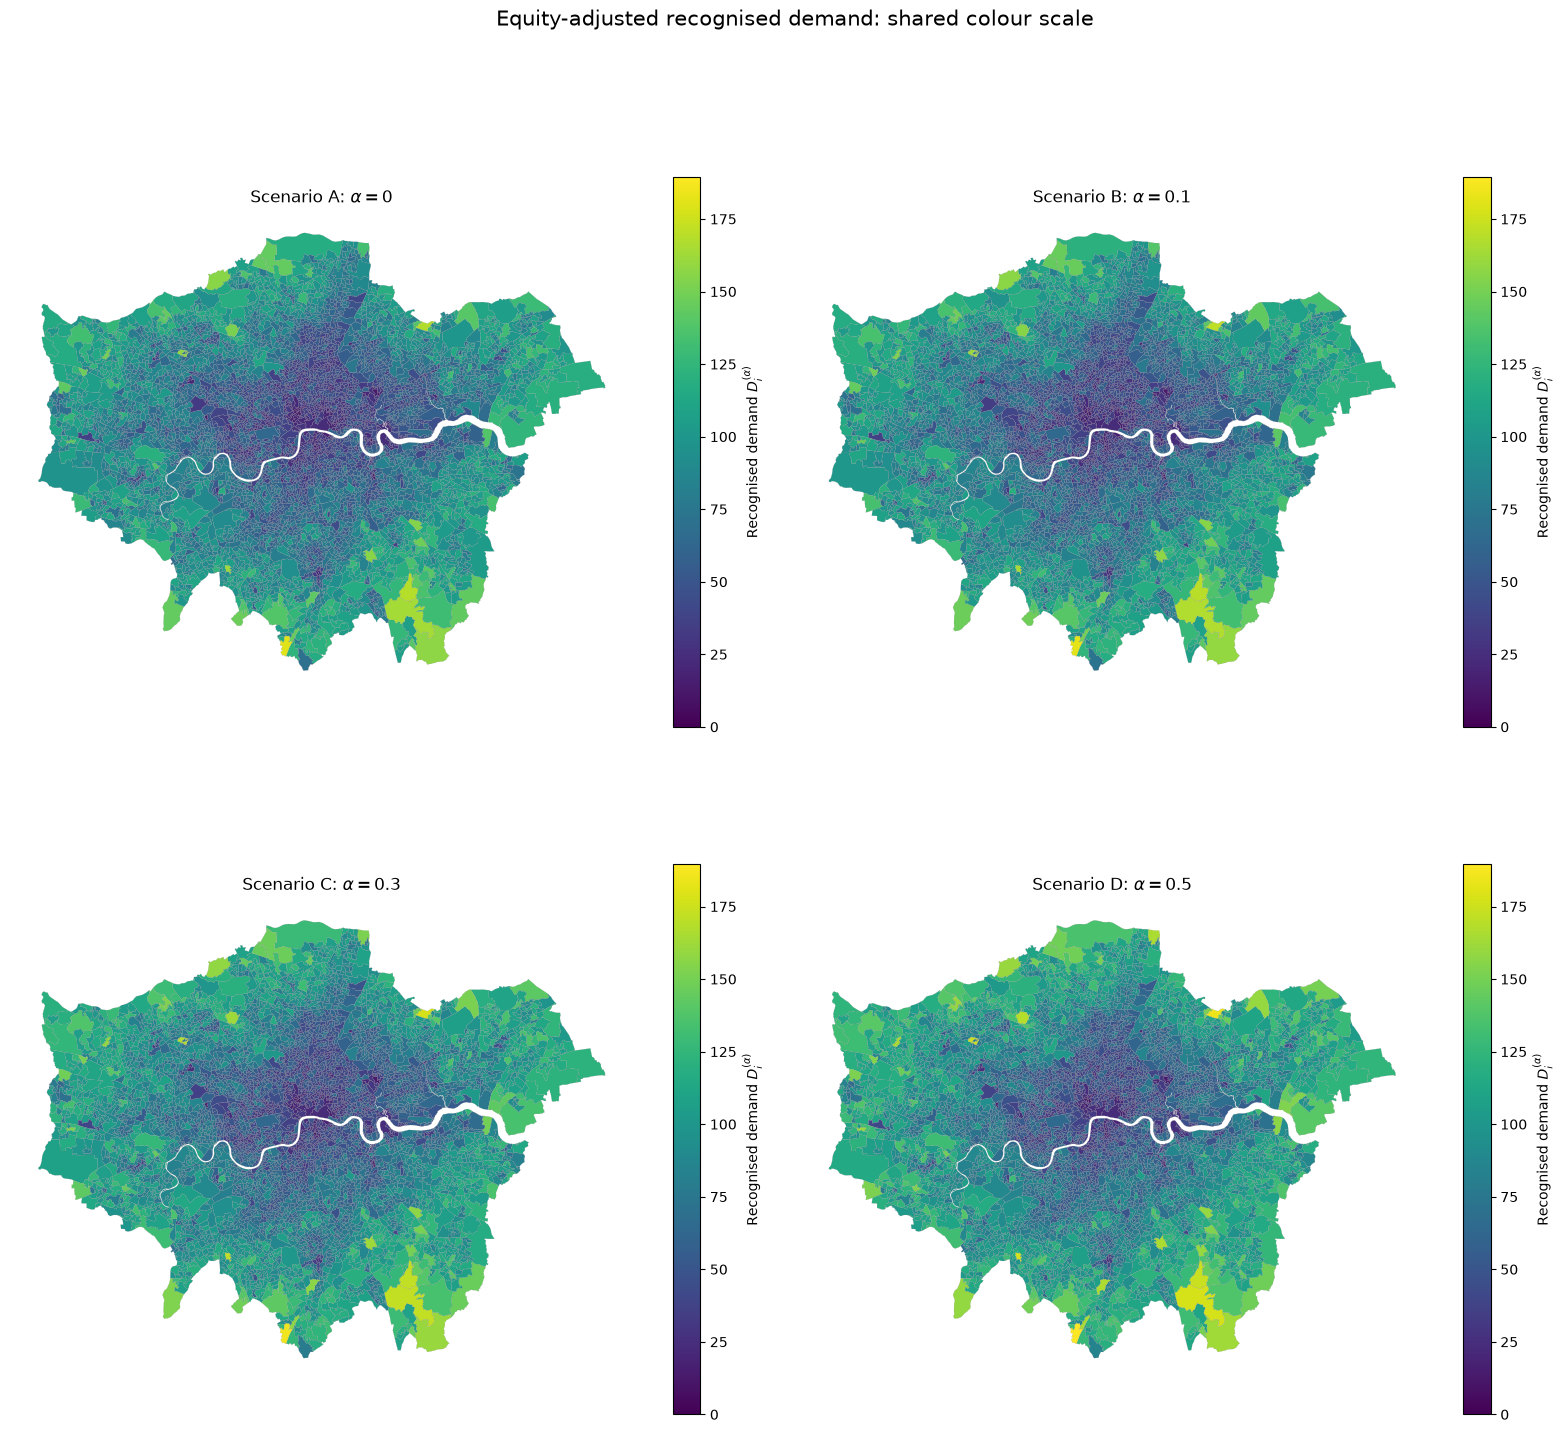

In [9]:
lsoa_boundaries = gpd.read_file(PATHS["boundaries"])
if lsoa_boundaries.crs is None:
    lsoa_boundaries = lsoa_boundaries.set_crs(epsg=27700)
elif lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

lsoa_london = (
    lsoa_boundaries.loc[
        lsoa_boundaries["LSOA21CD"].isin(analytical["lsoa_code"])
    ]
    .rename(columns={"LSOA21CD": "lsoa_code"})
    [["lsoa_code", "geometry"]]
    .merge(
        analytical[["lsoa_code"] + scenario_cols],
        on="lsoa_code",
        how="inner",
        validate="one_to_one",
    )
)

if len(lsoa_london) != len(analytical):
    raise ValueError("Not all analytical LSOAs matched the boundary file.")

scenario_titles = {
    "A": r"Scenario A: $\alpha=0$",
    "B": r"Scenario B: $\alpha=0.1$",
    "C": r"Scenario C: $\alpha=0.3$",
    "D": r"Scenario D: $\alpha=0.5$",
}
shared_vmax = analytical[scenario_cols].max().max()

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
for ax, label in zip(axes.flat, SCENARIOS):
    lsoa_london.plot(
        column=f"D_{label}",
        ax=ax,
        cmap="viridis",
        vmin=0,
        vmax=shared_vmax,
        linewidth=0.1,
        edgecolor="grey",
        legend=True,
        legend_kwds={"label": r"Recognised demand $D_i^{(\alpha)}$", "shrink": 0.65},
    )
    ax.set_title(scenario_titles[label])
    ax.axis("off")
plt.suptitle("Equity-adjusted recognised demand: shared colour scale", fontsize=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_demand_scenarios_shared_scale.png", dpi=300, bbox_inches="tight")
plt.show()

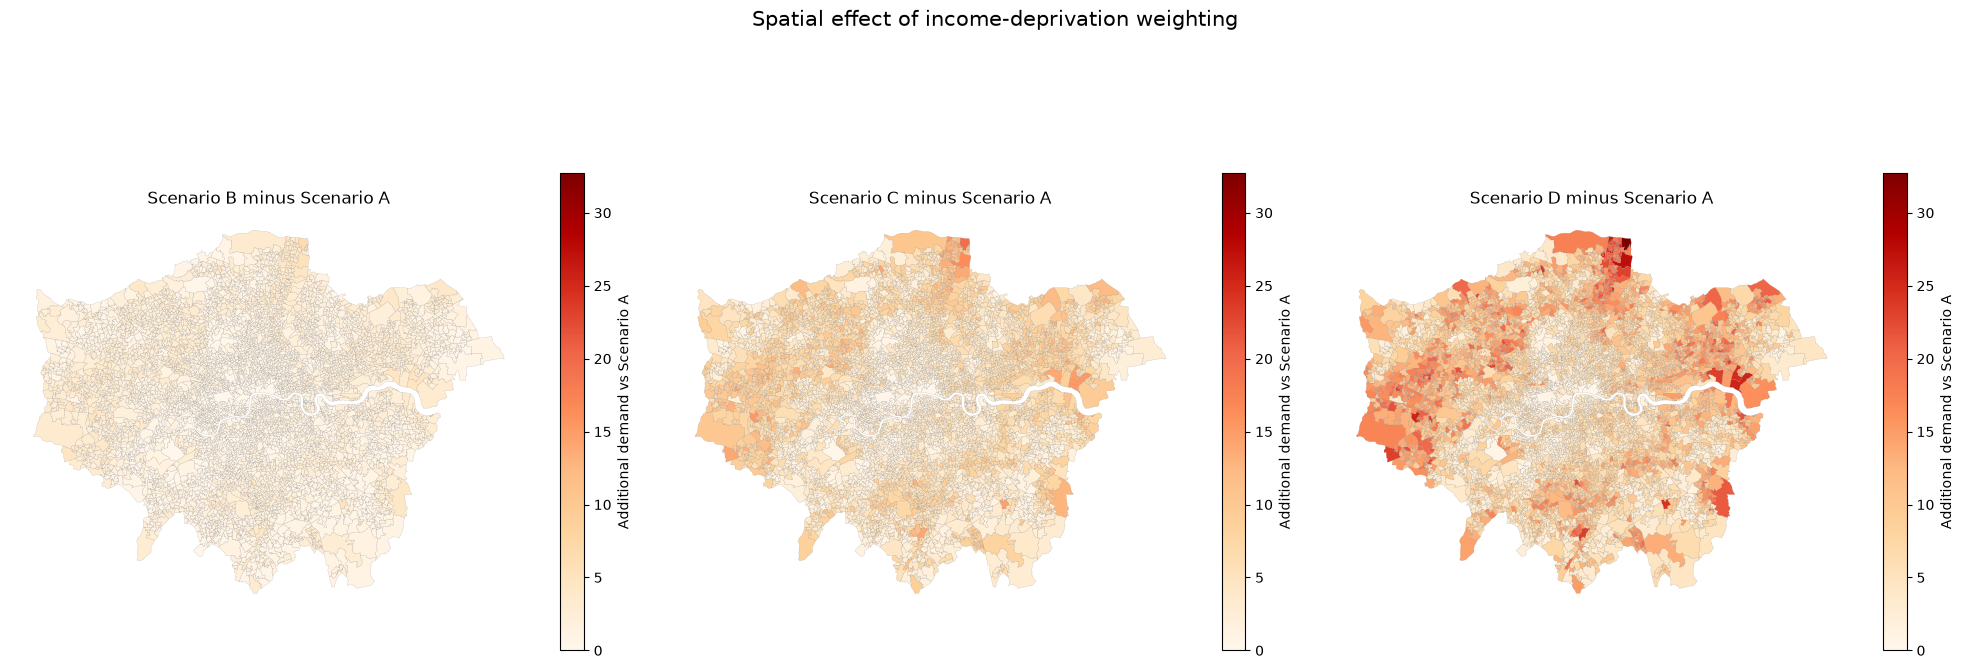

In [13]:
delta_map = lsoa_london.copy()
for label in ["B", "C", "D"]:
    delta_map[f"delta_{label}"] = delta_map[f"D_{label}"] - delta_map["D_A"]

shared_delta_max = delta_map[["delta_B", "delta_C", "delta_D"]].max().max()
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, label in zip(axes, ["B", "C", "D"]):
    delta_map.plot(
        column=f"delta_{label}",
        ax=ax,
        cmap="OrRd",
        vmin=0,
        vmax=shared_delta_max,
        linewidth=0.1,
        edgecolor="grey",
        legend=True,
        legend_kwds={"label": "Additional demand vs Scenario A", "shrink": 0.65},
    )
    ax.set_title(f"Scenario {label} minus Scenario A")
    ax.axis("off")
plt.suptitle("Spatial effect of income-deprivation weighting", fontsize=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_demand_delta_vs_A.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Export Phase 1 outputs

`demand_london.csv` contains the fixed inputs needed by Notebook 05, all four scenario-specific demand weights, and both national and London-specific deprivation deciles.

In [11]:
output_columns = [
    "lsoa_code", "lsoa_name",
    "Hi", "Ci", "V_i",
    "e_i", "u_i", "U_i", "S_eff_i", "has_evse_i",
    "IMD_i", "income_rank", "income_decile", "london_income_decile",
    "B_i", "D_A", "D_B", "D_C", "D_D",
]

demand_output = analytical[output_columns].copy()

demand_path = PROCESSED_DIR / "demand_london.csv"
scenario_summary_path = PROCESSED_DIR / "demand_scenario_summary.csv"
decile_summary_path = PROCESSED_DIR / "demand_by_london_decile.csv"

demand_output.to_csv(demand_path, index=False)
scenario_summary.to_csv(scenario_summary_path, index=False)
demand_by_decile.to_csv(decile_summary_path, index=False)

print("Saved:")
print(" -", demand_path)
print(" -", scenario_summary_path)
print(" -", decile_summary_path)

# Update the pipeline summary only when the file already exists.
pipeline_path = PROCESSED_DIR / "pipeline_summary.csv"
if pipeline_path.exists():
    pipeline = pd.read_csv(pipeline_path)
    item = "Demand D_i(alpha) computed (4 scenarios A-D)"
    value = (
        f"Done — {len(demand_output):,} LSOAs; "
        f"alpha=0 total={demand_output['D_A'].sum():,.2f}; "
        f"alpha=0.5 total={demand_output['D_D'].sum():,.2f}"
    )
    if {"Item", "Count"}.issubset(pipeline.columns):
        if pipeline["Item"].eq(item).any():
            pipeline.loc[pipeline["Item"].eq(item), "Count"] = value
        else:
            pipeline = pd.concat(
                [pipeline, pd.DataFrame([{"Item": item, "Count": value}])],
                ignore_index=True,
            )
        pipeline.to_csv(pipeline_path, index=False)
        print("Updated:", pipeline_path)

Saved:
 - /Users/alexia/Documents/CASA/Dissertation/05_processed/demand_london.csv
 - /Users/alexia/Documents/CASA/Dissertation/05_processed/demand_scenario_summary.csv
 - /Users/alexia/Documents/CASA/Dissertation/05_processed/demand_by_london_decile.csv


## 9. Handoff to Notebook 05

Notebook 05 should use:

- `D_A`, `D_B`, `D_C`, `D_D` as scenario-specific optimisation weights;
- `D_A = D_i^(0)` as the fixed evaluation weight for all cross-scenario metrics;
- `e_i` as existing on-street provision;
- `london_income_decile` for M3 and M4.